<a href="https://colab.research.google.com/github/Sachini1485/Electrical-Fault-Classification-PyTorch/blob/main/Fault_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electrical Fault Classification Using Deep Learning and PyTorch

## Objective

The objective of this project is to classify electrical power system faults using voltage and current measurements. A feedforward neural network was developed using PyTorch to automatically identify fault categories including LG, LL, LLG, LLL, LLLG, and No Fault conditions.

## Dataset Features

Input Features:
- Ia
- Ib
- Ic
- Va
- Vb
- Vc

Output Classes:
- LG        - 0
- LL        - 1
- LLG       - 2
- LLL       - 3
- LLLG      - 4
- No Fault  - 5

Import Libraries

In [48]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader



Load Dataset

In [49]:
df = pd.read_csv('classData.csv')

df.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


Dataset Exploration

In [50]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.head()

Shape: (7861, 10)

Columns:
Index(['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc'], dtype='object')


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


In [51]:
print(df[['G','C','B','A']].value_counts())

G  C  B  A
0  0  0  0    2365
1  0  1  1    1134
   1  1  1    1133
   0  0  1    1129
0  1  1  1    1096
         0    1004
Name: count, dtype: int64


In [52]:
df['Pattern'] = (
    df['G'].astype(str) +
    df['C'].astype(str) +
    df['B'].astype(str) +
    df['A'].astype(str)
)

print(df['Pattern'].value_counts())

Pattern
0000    2365
1011    1134
1111    1133
1001    1129
0111    1096
0110    1004
Name: count, dtype: int64


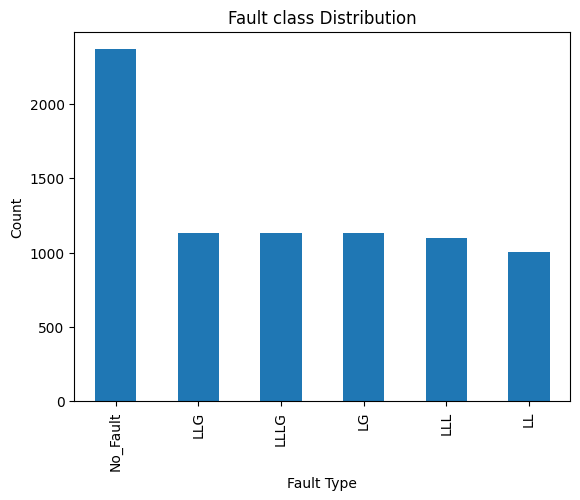

In [53]:
fault_map = {
    '0000':'No_Fault',
    '1001':'LG',
    '0110':'LL',
    '1011':'LLG',
    '0111':'LLL',
    '1111':'LLLG'
}

df['Fault'] = df['Pattern'].map(fault_map)

df['Fault'].value_counts().plot(kind='bar')

plt.title("Fault class Distribution")
plt.xlabel("Fault Type")
plt.ylabel("Count")
plt.show()

Data Preprocessing

In [54]:
X = df[['Ia','Ib','Ic','Va','Vb','Vc']]

In [55]:
y = df['Fault']

In [56]:
encoder = LabelEncoder()
y= encoder.fit_transform(y)

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [58]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


PyTorch Tensor Conversion

In [59]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

print(X_train.shape)
print(y_train.shape)

torch.Size([6288, 6])
torch.Size([6288])


DataLoader Creation

In [60]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train,y_train)
test_dataset = TensorDataset(X_test,y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size = 64,
    shuffle = True

)

test_loader = DataLoader(
    test_dataset,
    batch_size = 64
)

Neural Network Model

In [61]:
class FaultNet(nn.Module):

  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(
        nn.Linear(6,128),
        nn.ReLU(),
        nn.Dropout(0.2),

        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(0.2),

        nn.Linear(64,32),
        nn.ReLU(),

        nn.Linear(32,6),

    )

  def forward(self,x):
    return self.network(x)

model = FaultNet()
print(model)

FaultNet(
  (network): Sequential(
    (0): Linear(in_features=6, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=6, bias=True)
  )
)


Training

In [62]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [63]:
losses = []
epochs = 200
for epoch in range(epochs):
  model.train()
  epoch_loss = 0

  for batch_X,batch_y in train_loader:
      outputs = model(batch_X)
      loss=criterion(outputs,batch_y)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      epoch_loss += loss.item()
  losses.append(epoch_loss)

  if(epoch+1)%20==0:
    print(f"Epoch{epoch+1}/{epochs},Loss:{loss.item():.4f}")

Epoch20/200,Loss:0.4199
Epoch40/200,Loss:0.1891
Epoch60/200,Loss:0.2336
Epoch80/200,Loss:0.2161
Epoch100/200,Loss:0.3024
Epoch120/200,Loss:0.2269
Epoch140/200,Loss:0.2339
Epoch160/200,Loss:0.1816
Epoch180/200,Loss:0.1044
Epoch200/200,Loss:0.1439


Accuracy Evaluation

In [64]:
with torch.no_grad():
  outputs = model(X_test)
  _, predicted = torch.max(outputs,1)
  accuracy = (predicted == y_test).float().mean()

print("Accuracy:", accuracy.item())

Accuracy: 0.8582326769828796


Classification Report

In [65]:
report = classification_report(
       y_test.numpy(),
       predicted.numpy(),
       target_names=encoder.classes_
    )

print(report)

with open("classification_report.txt", "w") as f:
    f.write(report)

              precision    recall  f1-score   support

          LG       0.98      1.00      0.99       226
          LL       0.99      1.00      1.00       201
         LLG       0.99      0.98      0.98       227
         LLL       0.51      0.65      0.57       219
        LLLG       0.54      0.38      0.44       227
    No_Fault       1.00      1.00      1.00       473

    accuracy                           0.86      1573
   macro avg       0.83      0.83      0.83      1573
weighted avg       0.86      0.86      0.86      1573



Confusion Matrix

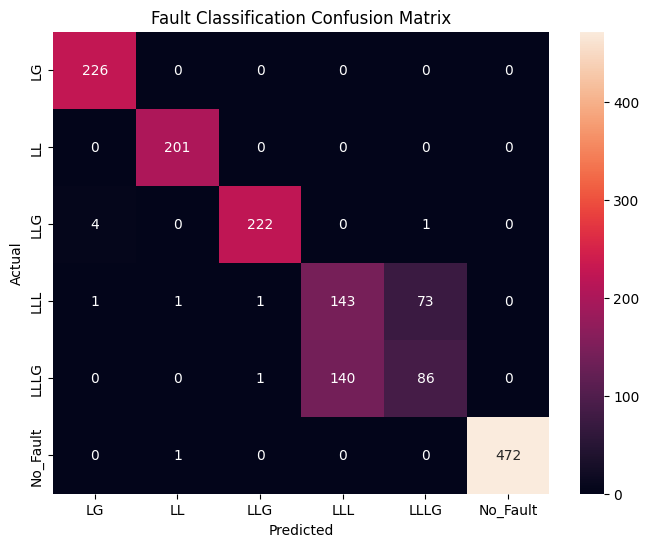

<Figure size 640x480 with 0 Axes>

In [66]:
cm = confusion_matrix(
    y_test.numpy(),
    predicted.numpy(),

)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fault Classification Confusion Matrix")
plt.show()

plt.savefig("confusion_matrix.png")

Loss Curve

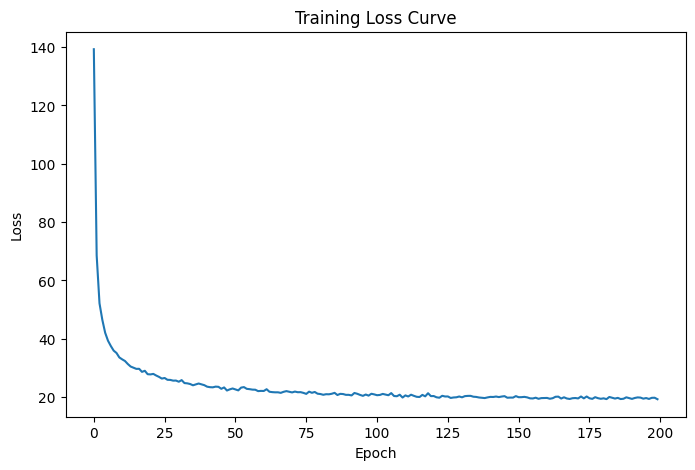

In [67]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show

plt.savefig("loss_curve.png")

Testing the Model on a New Sample

In [68]:
Ia = float(input("Enter Ia:"))
Ib = float(input("Enter Ib:"))
Ic = float(input("Enter Ic:"))
Va = float(input("Enter va:"))
Vb = float(input("Enter vb:"))
Vc = float(input("Enter vc:"))

input_data = torch.tensor(
[
[Ia,Ib,Ic,Va,Vb,Vc]
],
dtype=torch.float32
)

with torch.no_grad():
  result = model(input_data)
  fault = torch.argmax(result)

print("Detected fault class:", fault.item())

Enter Ia:0.5
Enter Ib:-1.2
Enter Ic:0.8
Enter va:1.1
Enter vb:-0.3
Enter vc:0.6
Detected fault class: 3


#conclusion

A deep learning-based fault classification system was successfully developed using PyTorch. By utilizing current and voltage measurements as input features, the model achieved an overall test accuracy aound 86%. The system demonstrated excellent performance in detecting LG, LL, LLG, and No Fault conditions, while maintaining acceptable performance reducing the need for manual inspection and enabling faster fault detection.
